## Principle Component Analysis

### Data Loading and Preparation

#### **Input Files:**
- `class.tsv`: Contains binary classification labels (0 for ER-, 1 for ER+).
- `filtered.tsv`: Gene expression data matrix (tab-separated format).
- `columns.tsv`: Gene mapping file linking gene symbols to column indices.

#### **Data Extraction Steps:**
- Loads ER status labels for each sample.
- Loads expression data for various genes.
- Uses gene mapping to identify the columns corresponding to **GATA3** and **XBP1**.
- Extracts the expression values for these two genes.
- Constructs a `DataFrame` with expression values for GATA3 and XBP1 only.

---

### PCA Implementation

The PCA algorithm is implemented **from scratch**, without using high-level PCA libraries.

#### **1. Data Centering**
- Subtract the mean from each gene's expression values to center the data.

#### **2. Covariance Matrix Calculation**
- Compute the **2×2 covariance matrix** of the centered data (GATA3 and XBP1).

#### **3. Eigendecomposition**
- Calculate **eigenvalues** and **eigenvectors** of the covariance matrix.
- Sort eigenvalues and corresponding eigenvectors in **descending order**.
- Eigenvectors define the **principal component (PC) directions**.

#### **4. Projection**
- Project the centered data onto the PC1 and PC2 axes.

---

### Visualization Creation

A **three-panel plot** is generated to visualize PCA results and ER status separation.

#### **Panel A - Original Data**
- Scatter plot: **GATA3 vs. XBP1** expression.
- Points colored by ER status:
  - Black: ER-
  - Red: ER+
- Displays original data distribution.

#### **Panel B - PCA Directions**
- Same scatter plot as Panel A.
- Adds **arrows** for PC1 and PC2 directions.
- Highlights directions of **maximum variance** in the data.

#### **Panel C - PC1 Projections**
- One-dimensional plot of sample projections onto PC1.
- Three rows of samples:
  - Top row: All samples (colored by ER status).
  - Middle row: ER- samples (black).
  - Bottom row: ER+ samples (red).
- Shows how well PC1 separates ER+ and ER- samples.

---

### Results Analysis

The final output of the code includes:

- **Explained variance ratio** of PC1 (how much variance is captured).
- **Direction vectors** (coefficients for GATA3 and XBP1) for PC1 and PC2.
- Comparison to published results, showing PC1 as a **weighted combination** of GATA3 and XBP1.


Loaded 105 class labels
Loaded expression data with shape: (105, 16174)
Loaded gene mapping with 27648 entries
Found GATA3 ID: 4359
Found XBP1 ID: 4404


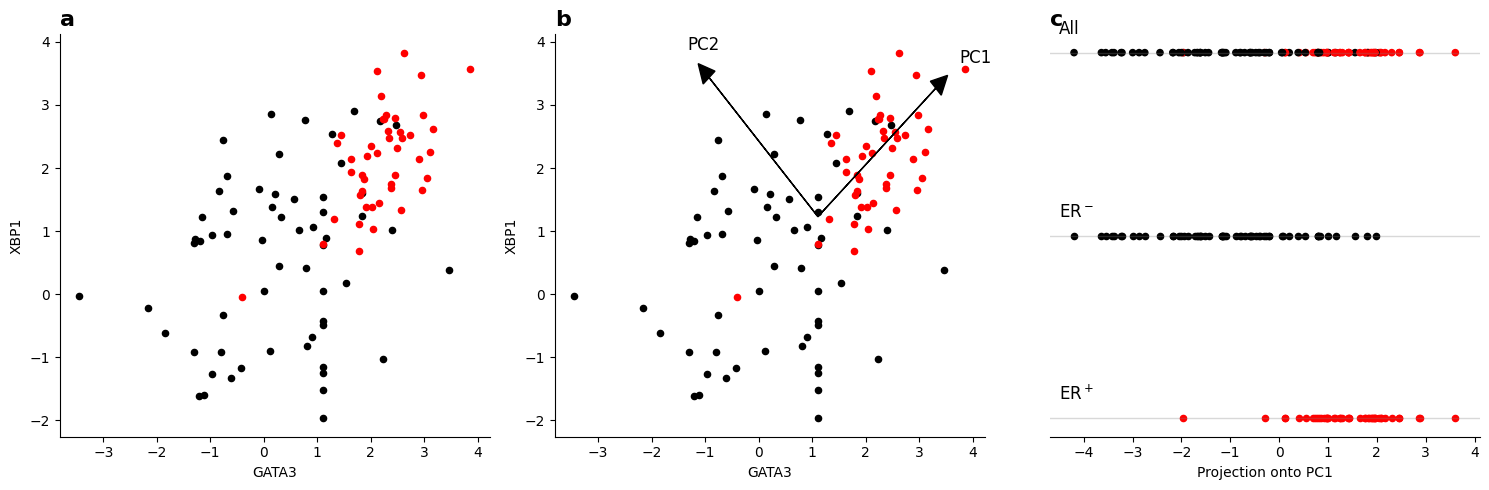


Manual PCA Results:
Explained variance ratio by PC1: 0.7792
PC1 direction (GATA3, XBP1): [0.7347, 0.6784]
PC2 direction (GATA3, XBP1): [-0.6784, 0.7347]

Paper reports PC1 = 0.83 × GATA3 + 0.56 × XBP1
Our manual implementation: PC1 = 0.73 × GATA3 + 0.68 × XBP1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io

# Load data
class_file = 'class.tsv'
expression_file = 'filtered.tsv'
columns_file = 'columns.tsv'

class_labels = pd.read_csv(class_file, header=None)[0].values
print(f"Loaded {len(class_labels)} class labels")

expression_data = pd.read_csv(expression_file, sep='\t')
print(f"Loaded expression data with shape: {expression_data.shape}")

with open(columns_file, 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]

column_data_str = ''.join(lines)
gene_mapping = pd.read_csv(io.StringIO(column_data_str), sep='\t')
print(f"Loaded gene mapping with {len(gene_mapping)} entries")

gata3_info = gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']
xbp1_info = gene_mapping[gene_mapping['GeneSymbol'] == 'XBP1']

gata3_id = gata3_info['ID'].values[0]
xbp1_id = xbp1_info['ID'].values[0]

print(f"Found GATA3 ID: {gata3_id}")
print(f"Found XBP1 ID: {xbp1_id}")

# Extract expressions
gata3_expr = expression_data[" "+str(gata3_id)].values
xbp1_expr = expression_data[" "+str(xbp1_id)].values

expression_df = pd.DataFrame({
    'GATA3': gata3_expr,
    'XBP1': xbp1_expr
})

X = expression_df[['GATA3', 'XBP1']].values

X_centered = X - np.mean(X, axis=0)

cov_matrix = np.cov(X_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

principalComponents = np.dot(X_centered, eigenvectors)

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3)

ax1 = plt.subplot(gs[0, 0])
for er_status in [0, 1]:
    mask = class_labels == er_status
    color = 'black' if er_status == 0 else 'red'
    ax1.scatter(X[mask, 0], X[mask, 1], color=color, s=20)

ax1.set_xlabel('GATA3')
ax1.set_ylabel('XBP1')
ax1.set_title('a', loc='left', fontweight='bold', fontsize=16)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = plt.subplot(gs[0, 1])
for er_status in [0, 1]:
    mask = class_labels == er_status
    color = 'black' if er_status == 0 else 'red'
    ax2.scatter(X[mask, 0], X[mask, 1], color=color, s=20)

scale_factor = 3
origin = np.mean(X, axis=0)
ax2.arrow(origin[0], origin[1], scale_factor * pc1[0], scale_factor * pc1[1], head_width=0.3, head_length=0.3, fc='k', ec='k')
ax2.arrow(origin[0], origin[1], scale_factor * pc2[0], scale_factor * pc2[1], head_width=0.3, head_length=0.3, fc='k', ec='k')

ax2.text(origin[0] + scale_factor * pc1[0] * 1.2, origin[1] + scale_factor * pc1[1] * 1.2, "PC1", fontsize=12)
ax2.text(origin[0] + scale_factor * pc2[0] * 1.2, origin[1] + scale_factor * pc2[1] * 1.2, "PC2", fontsize=12)

ax2.set_xlabel('GATA3')
ax2.set_ylabel('XBP1')
ax2.set_title('b', loc='left', fontweight='bold', fontsize=16)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

xlims = list(ax1.get_xlim())
ylims = list(ax1.get_ylim())
ax2.set_xlim(xlims)
ax2.set_ylim(ylims)

ax3 = plt.subplot(gs[0, 2])

pc1_projections = principalComponents[:, 0]

all_y = 3
er_neg_y = 2
er_pos_y = 1

ax3.axhline(y=all_y, color='gray', linestyle='-', alpha=0.3, linewidth=1)
ax3.axhline(y=er_neg_y, color='gray', linestyle='-', alpha=0.3, linewidth=1)
ax3.axhline(y=er_pos_y, color='gray', linestyle='-', alpha=0.3, linewidth=1)

ax3.scatter(pc1_projections, [all_y] * len(pc1_projections), c=['red' if c == 1 else 'black' for c in class_labels], s=20)

er_neg_mask = class_labels == 0
ax3.scatter(pc1_projections[er_neg_mask], [er_neg_y] * sum(er_neg_mask), c='black', s=20)

er_pos_mask = class_labels == 1
ax3.scatter(pc1_projections[er_pos_mask], [er_pos_y] * sum(er_pos_mask), c='red', s=20)

ax3.text(-4.5, all_y + 0.1, "All", fontsize=12, ha='left')
ax3.text(-4.5, er_neg_y + 0.1, "ER$^-$", fontsize=12, ha='left')
ax3.text(-4.5, er_pos_y + 0.1, "ER$^+$", fontsize=12, ha='left')

ax3.set_xlabel('Projection onto PC1')
ax3.set_title('c', loc='left', fontweight='bold', fontsize=16)
ax3.set_yticks([])
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

x_min = min(pc1_projections)
x_max = max(pc1_projections)
ax3.set_xlim([x_min - 0.5, x_max + 0.5])

plt.tight_layout()
plt.show()

# Print results
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

print("\nManual PCA Results:")
print(f"Explained variance ratio by PC1: {explained_variance_ratio[0]:.4f}")
print(f"PC1 direction (GATA3, XBP1): [{pc1[0]:.4f}, {pc1[1]:.4f}]")
print(f"PC2 direction (GATA3, XBP1): [{pc2[0]:.4f}, {pc2[1]:.4f}]")

print("\nPaper reports PC1 = 0.83 × GATA3 + 0.56 × XBP1")
print(f"Our manual implementation: PC1 = {abs(pc1[0]):.2f} × GATA3 + {abs(pc1[1]):.2f} × XBP1")
